In [16]:
# ── Reproducibility ──────────────────────────────────────────────────────────
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


In [17]:
# ── Imports ───────────────────────────────────────────────────────────────────
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_mean_pool, global_max_pool, global_add_pool
from torch_geometric.utils import to_networkx, degree

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

print('All imports successful.')

All imports successful.


---
## 1. Dataset Selection & Description

### Why IMDB-Binary?
**IMDB-Binary (IMDB-B)** is a movie collaboration dataset where each graph represents a movie. Nodes are actors/actresses, and edges connect two actors if they appeared in the same movie. The classification task is to predict whether a movie belongs to the **Action** or **Romance** genre.

- **Nodes:** actors per movie  
- **Edges:** co-appearances  
- **Labels:** 0 = Action, 1 = Romance  
- **1,000 graphs total** — well above the 500-node, 1,000-edge requirement across the dataset  

**Source:** Yanardag, P. & Vishwanathan, S.V.N. (2015). *Deep Graph Kernels.* KDD 2015.  
Retrieved from TUDataset: https://chrsmrrs.github.io/datasets/docs/datasets/

In [18]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
dataset = TUDataset(root='./data', name='IMDB-BINARY')

print('=== Dataset Info ===')
print(f'  Number of graphs  : {len(dataset)}')
print(f'  Number of classes : {dataset.num_classes}')
print(f'  Number of features: {dataset.num_node_features}')

# Inspect a single graph
sample = dataset[0]
print(f'\nSample graph: {sample}')
print(f'  Nodes : {sample.num_nodes}')
print(f'  Edges : {sample.num_edges}')
print(f'  Label : {sample.y.item()}')

=== Dataset Info ===
  Number of graphs  : 1000
  Number of classes : 2
  Number of features: 0

Sample graph: Data(edge_index=[2, 146], y=[1], num_nodes=20)
  Nodes : 20
  Edges : 146
  Label : 0


---
## 2. Preprocessing

**IMDB-B has no node features** — nodes carry no attribute vector by default.
We engineer a degree-based feature vector for each node so the GNN has something to aggregate.

**Justification:** Degree is the most informative structural feature available and is commonly used for IMDB-B in the literature.

In [19]:
from torch_geometric.transforms import Compose, OneHotDegree

# Find the maximum degree across the dataset to set the feature dimension
max_degree = 0
for data in dataset:
    deg = degree(data.edge_index[0], num_nodes=data.num_nodes)
    max_degree = max(max_degree, int(deg.max().item()))

print(f'Maximum node degree across dataset: {max_degree}')

# Reload with OneHotDegree transform
transform = OneHotDegree(max_degree)
dataset = TUDataset(root='./data', name='IMDB-BINARY', transform=transform)

print(f'Node feature dimension after transform: {dataset.num_node_features}')
print(f'Sample node features shape: {dataset[0].x.shape}')

Maximum node degree across dataset: 135
Node feature dimension after transform: 136
Sample node features shape: torch.Size([20, 136])


In [20]:
# ── Train / Val / Test Split (70 / 15 / 15) ───────────────────────────────────
indices = list(range(len(dataset)))
labels  = [dataset[i].y.item() for i in indices]

train_idx, test_idx = train_test_split(indices, test_size=0.15, stratify=labels, random_state=SEED)
train_labels = [labels[i] for i in train_idx]
train_idx, val_idx = train_test_split(train_idx, test_size=0.15/0.85, stratify=train_labels, random_state=SEED)

train_data = [dataset[i] for i in train_idx]
val_data   = [dataset[i] for i in val_idx]
test_data  = [dataset[i] for i in test_idx]

print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

BATCH_SIZE = 32
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE)

Train: 700 | Val: 150 | Test: 150


---
## 3. Graph Analysis with NetworkX

We analyse structural properties across the dataset: degree distribution, clustering coefficient, and diameter.

In [21]:
# ── Convert a sample to NetworkX and compute stats ────────────────────────────
def compute_graph_stats(pyg_data):
    """Return basic NetworkX stats for a single PyG graph."""
    G = to_networkx(pyg_data, to_undirected=True)
    stats = {
        'nodes'      : G.number_of_nodes(),
        'edges'      : G.number_of_edges(),
        'avg_degree' : np.mean([d for _, d in G.degree()]),
        'density'    : nx.density(G),
        'clustering' : nx.average_clustering(G),
    }
    # Diameter only defined for connected graphs
    if nx.is_connected(G):
        stats['diameter'] = nx.diameter(G)
    else:
        lcc = G.subgraph(max(nx.connected_components(G), key=len))
        stats['diameter'] = nx.diameter(lcc)
    return stats, G

# Compute over a random sample of 200 graphs for speed
sample_idx = random.sample(range(len(dataset)), 200)
stats_list = []
for i in sample_idx:
    s, _ = compute_graph_stats(dataset[i])
    s['label'] = dataset[i].y.item()
    stats_list.append(s)

stats_df = pd.DataFrame(stats_list)
print('=== Dataset Statistics (200-graph sample) ===')
print(stats_df.describe().round(3))

=== Dataset Statistics (200-graph sample) ===
         nodes    edges  avg_degree  density  clustering  diameter    label
count  200.000  200.000     200.000  200.000     200.000   200.000  200.000
mean    20.430  103.430       9.085    0.507       0.948     1.875    0.535
std      9.923  112.626       5.542    0.240       0.031     0.332    0.500
min     12.000   26.000       4.059    0.095       0.860     1.000    0.000
25%     14.000   46.000       6.000    0.330       0.927     2.000    0.000
50%     17.000   66.000       7.038    0.436       0.953     2.000    1.000
75%     24.250  104.250       9.393    0.585       0.966     2.000    1.000
max     72.000  785.000      29.000    1.000       1.000     2.000    1.000


/tmp/ipykernel_55918/3289102739.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stats_df, x='label', y='clustering', palette=['#e07b54', '#5b8db8'], ax=axes[1])
/tmp/ipykernel_55918/3289102739.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['Action (0)', 'Romance (1)'])
/tmp/ipykernel_55918/3289102739.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stats_df, x='label', y='diameter', palette=['#e07b54', '#5b8db8'], ax=axes[2])
/tmp/ipykernel_55918/3289102739.py:23: UserWarning: set_ticklabels() should only be used with a fi

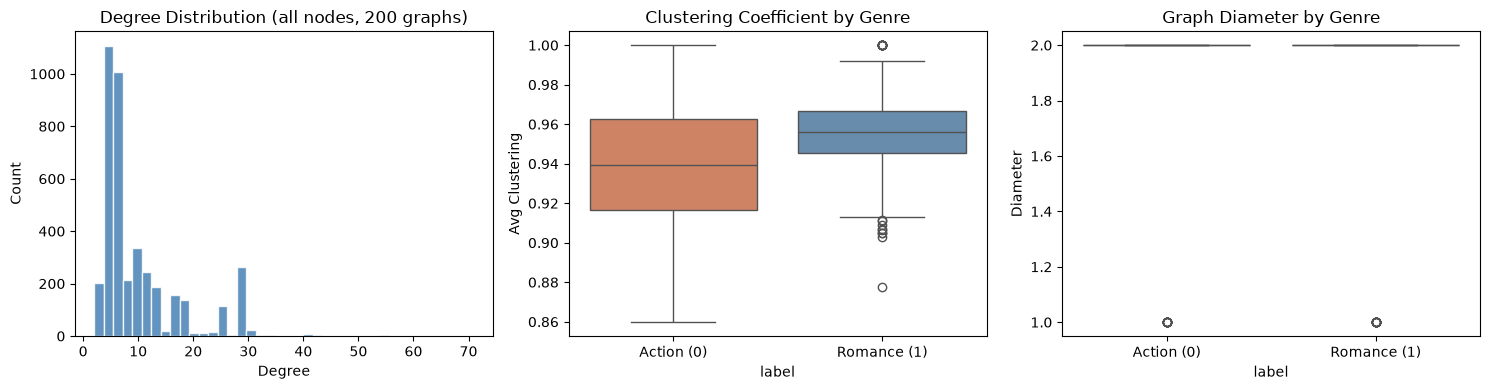

Saved: graph_stats.png


In [22]:
# ── Visualize Degree Distribution ─────────────────────────────────────────────
all_degrees = []
for i in sample_idx:
    G = to_networkx(dataset[i], to_undirected=True)
    all_degrees.extend([d for _, d in G.degree()])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Degree distribution
axes[0].hist(all_degrees, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Degree Distribution (all nodes, 200 graphs)', fontsize=12)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')

# Clustering coefficient by label
sns.boxplot(data=stats_df, x='label', y='clustering', palette=['#e07b54', '#5b8db8'], ax=axes[1])
axes[1].set_xticklabels(['Action (0)', 'Romance (1)'])
axes[1].set_title('Clustering Coefficient by Genre', fontsize=12)
axes[1].set_ylabel('Avg Clustering')

# Graph diameter by label
sns.boxplot(data=stats_df, x='label', y='diameter', palette=['#e07b54', '#5b8db8'], ax=axes[2])
axes[2].set_xticklabels(['Action (0)', 'Romance (1)'])
axes[2].set_title('Graph Diameter by Genre', fontsize=12)
axes[2].set_ylabel('Diameter')

plt.tight_layout()
plt.savefig('graph_stats.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: graph_stats.png')

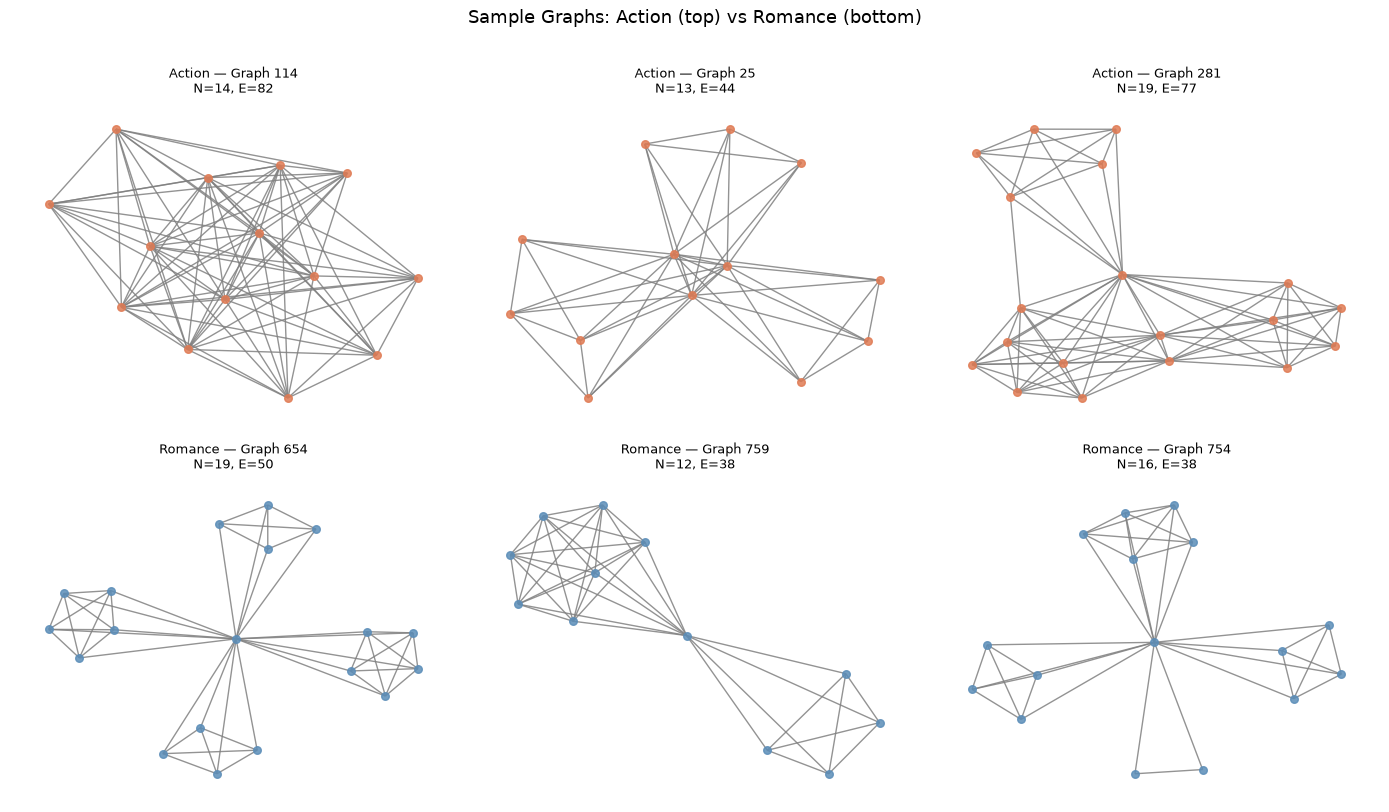

Saved: sample_graphs.png


In [23]:
# ── Visualize Sample Graphs per Class ─────────────────────────────────────────
action_idx  = [i for i in sample_idx if dataset[i].y.item() == 0][:3]
romance_idx = [i for i in sample_idx if dataset[i].y.item() == 1][:3]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
labels_row = ['Action', 'Romance']
for row, idxs in enumerate([action_idx, romance_idx]):
    for col, gi in enumerate(idxs):
        G = to_networkx(dataset[gi], to_undirected=True)
        pos = nx.spring_layout(G, seed=SEED)
        nx.draw_networkx(G, pos, ax=axes[row][col], node_size=30,
                         node_color='#e07b54' if row == 0 else '#5b8db8',
                         edge_color='grey', with_labels=False, alpha=0.85)
        axes[row][col].set_title(f'{labels_row[row]} — Graph {gi}\n'
                                 f'N={G.number_of_nodes()}, E={G.number_of_edges()}',
                                 fontsize=9)
        axes[row][col].axis('off')

plt.suptitle('Sample Graphs: Action (top) vs Romance (bottom)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('sample_graphs.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: sample_graphs.png')

---
## 4. GNN Architecture Design

### Architecture: GIN (Graph Isomorphism Network)

**Why GIN?**  
Graph Classification requires a model that can distinguish non-isomorphic graphs. GIN, proposed by Xu et al. (2019), is theoretically as powerful as the Weisfeiler-Lehman graph isomorphism test — the most expressive message-passing GNN possible. For a task where graph-level structural differences define classes, this is the best-suited architecture.

**Architecture choices:**
| Choice | Value | Justification |
|--------|-------|---------------|
| GNN layers | 3 | Captures 3-hop neighbourhoods; IMDB-B graphs are small |
| Hidden dim | 64 | Balances expressiveness and overfitting risk on 1000 graphs |
| Pooling | Mean + Max (concat) | Mean captures global density; Max captures prominent nodes |
| Dropout | 0.5 | Regularisation; dataset is small |
| Activation | ReLU | Standard, stable |
| ε | Learnable | Lets the model learn the self-loop weight |

In [24]:
class GINClassifier(nn.Module):
    """Graph Isomorphism Network for graph-level binary classification."""

    def __init__(self, in_channels, hidden_channels, num_classes, num_layers=3, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        for i in range(num_layers):
            in_ch = in_channels if i == 0 else hidden_channels
            # Each GINConv wraps a 2-layer MLP
            mlp = nn.Sequential(
                nn.Linear(in_ch, hidden_channels),
                nn.ReLU(),
                nn.Linear(hidden_channels, hidden_channels),
            )
            self.convs.append(GINConv(mlp, train_eps=True))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Readout: concatenate mean and max pooling → 2*hidden_channels
        self.classifier = nn.Sequential(
            nn.Linear(2 * hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, num_classes),
        )

    def forward(self, x, edge_index, batch):
        # Message passing
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=0.5, training=self.training)

        # Graph-level readout
        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        x_graph = torch.cat([x_mean, x_max], dim=1)   # (B, 2*hidden)

        return self.classifier(x_graph)                # (B, num_classes)


# Instantiate
IN_CHANNELS  = dataset.num_node_features
HIDDEN       = 64
NUM_CLASSES  = dataset.num_classes

model = GINClassifier(
    in_channels=IN_CHANNELS,
    hidden_channels=HIDDEN,
    num_classes=NUM_CLASSES,
    num_layers=3,
    dropout=0.5,
).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

GINClassifier(
  (convs): ModuleList(
    (0): GINConv(nn=Sequential(
      (0): Linear(in_features=136, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    ))
    (1-2): 2 x GINConv(nn=Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    ))
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)

Trainable parameters: 38,341


---
## 5. Training Loop

In [25]:
# ── Optimiser & Loss ──────────────────────────────────────────────────────────
# Adam with weight decay for regularisation
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# Learning-rate scheduler: reduce on plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=10
)


def train_epoch(loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        out  = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        pred = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total   += batch.num_graphs

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        out  = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)

        total_loss += loss.item() * batch.num_graphs
        pred = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total   += batch.num_graphs

    return total_loss / total, correct / total

In [26]:
# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS = 150
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
best_state   = None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(train_loader)
    vl_loss, vl_acc = evaluate(val_loader)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    scheduler.step(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
              f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}')

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

# Restore best weights
model.load_state_dict(best_state)

Epoch  10 | Train Loss: 0.4995 Acc: 0.7371 | Val Loss: 0.4775 Acc: 0.7867
Epoch  20 | Train Loss: 0.4517 Acc: 0.7614 | Val Loss: 0.4384 Acc: 0.8200
Epoch  30 | Train Loss: 0.4060 Acc: 0.7786 | Val Loss: 0.4098 Acc: 0.8267
Epoch  40 | Train Loss: 0.3840 Acc: 0.8014 | Val Loss: 0.4239 Acc: 0.8267
Epoch  50 | Train Loss: 0.3637 Acc: 0.8186 | Val Loss: 0.4355 Acc: 0.8400
Epoch  60 | Train Loss: 0.3547 Acc: 0.8300 | Val Loss: 0.4263 Acc: 0.8267
Epoch  70 | Train Loss: 0.3478 Acc: 0.8214 | Val Loss: 0.4318 Acc: 0.8400
Epoch  80 | Train Loss: 0.3485 Acc: 0.8171 | Val Loss: 0.4314 Acc: 0.8400
Epoch  90 | Train Loss: 0.3595 Acc: 0.8171 | Val Loss: 0.4300 Acc: 0.8333
Epoch 100 | Train Loss: 0.3443 Acc: 0.8286 | Val Loss: 0.4293 Acc: 0.8467
Epoch 110 | Train Loss: 0.3571 Acc: 0.8214 | Val Loss: 0.4357 Acc: 0.8400
Epoch 120 | Train Loss: 0.3604 Acc: 0.8271 | Val Loss: 0.4380 Acc: 0.8267
Epoch 130 | Train Loss: 0.3325 Acc: 0.8171 | Val Loss: 0.4311 Acc: 0.8333
Epoch 140 | Train Loss: 0.3559 Acc: 0.

<All keys matched successfully>

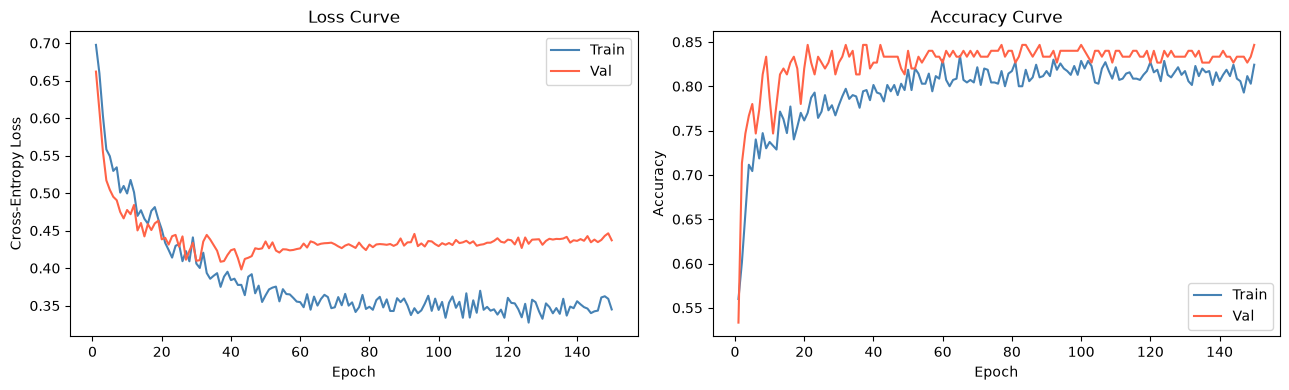

Saved: training_curves.png


In [27]:
# ── Plot Training Curves ──────────────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_range, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], label='Train', color='steelblue')
axes[1].plot(epochs_range, history['val_acc'],   label='Val',   color='tomato')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

---
## 6. Evaluation

In [28]:
@torch.no_grad()
def get_predictions(loader):
    """Return all true labels, predicted labels, and softmax probs."""
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    graph_data_list = []

    for batch in loader:
        batch = batch.to(DEVICE)
        out   = model(batch.x, batch.edge_index, batch.batch)
        prob  = F.softmax(out, dim=1)

        y_true.extend(batch.y.cpu().tolist())
        y_pred.extend(out.argmax(dim=1).cpu().tolist())
        y_prob.extend(prob.cpu().tolist())

    return np.array(y_true), np.array(y_pred), np.array(y_prob)


y_true, y_pred, y_prob = get_predictions(test_loader)

acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average='macro')

print('======= Test Set Evaluation =======')
print(f'  Accuracy (macro) : {acc:.4f}')
print(f'  F1 Score (macro) : {f1:.4f}')
print()
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=['Action', 'Romance']))

======= Test Set Evaluation =======
  Accuracy (macro) : 0.7200
  F1 Score (macro) : 0.7198

Classification Report:
              precision    recall  f1-score   support

      Action       0.73      0.69      0.71        75
     Romance       0.71      0.75      0.73        75

    accuracy                           0.72       150
   macro avg       0.72      0.72      0.72       150
weighted avg       0.72      0.72      0.72       150



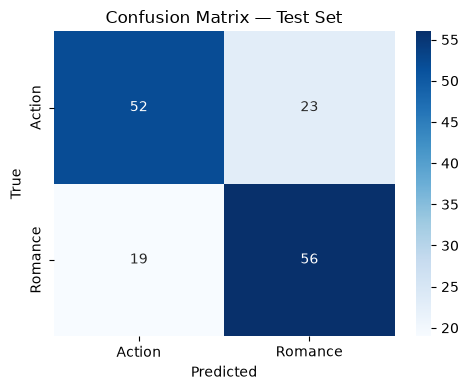

Saved: confusion_matrix.png


In [29]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Action', 'Romance'],
            yticklabels=['Action', 'Romance'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

---
## 7. Pooling Strategy Comparison

We compare three readout strategies to justify our choice (Mean+Max concat).

Pooling=mean     → Test Acc: 0.7733
Pooling=max      → Test Acc: 0.7400
Pooling=add      → Test Acc: 0.7400
Pooling=concat   → Test Acc: 0.7267


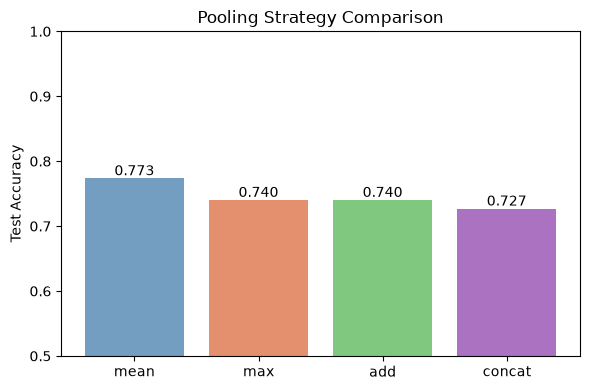

Saved: pooling_comparison.png


In [30]:
class GINWithPooling(nn.Module):
    """GIN variant with a selectable pooling strategy."""

    def __init__(self, in_channels, hidden_channels, num_classes,
                 pooling='mean', num_layers=3, dropout=0.5):
        super().__init__()
        self.pooling = pooling
        self.convs   = nn.ModuleList()
        self.bns     = nn.ModuleList()

        for i in range(num_layers):
            in_ch = in_channels if i == 0 else hidden_channels
            mlp   = nn.Sequential(
                nn.Linear(in_ch, hidden_channels), nn.ReLU(),
                nn.Linear(hidden_channels, hidden_channels),
            )
            self.convs.append(GINConv(mlp, train_eps=True))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        pool_out = 2 * hidden_channels if pooling == 'concat' else hidden_channels
        self.classifier = nn.Sequential(
            nn.Linear(pool_out, hidden_channels), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, num_classes),
        )

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x, edge_index)))
            x = F.dropout(x, p=0.5, training=self.training)

        if self.pooling == 'mean':
            x = global_mean_pool(x, batch)
        elif self.pooling == 'max':
            x = global_max_pool(x, batch)
        elif self.pooling == 'add':
            x = global_add_pool(x, batch)
        elif self.pooling == 'concat':
            x = torch.cat([global_mean_pool(x, batch),
                           global_max_pool(x, batch)], dim=1)
        return self.classifier(x)


def quick_train(pooling_name, epochs=80):
    """Train a pooling variant and return test accuracy."""
    m = GINWithPooling(IN_CHANNELS, HIDDEN, NUM_CLASSES, pooling=pooling_name).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=0.001, weight_decay=1e-4)
    best_val, best_st = 0.0, None

    for _ in range(epochs):
        m.train()
        for b in train_loader:
            b = b.to(DEVICE)
            opt.zero_grad()
            loss = criterion(m(b.x, b.edge_index, b.batch), b.y)
            loss.backward(); opt.step()
        m.eval()
        with torch.no_grad():
            correct = total = 0
            for b in val_loader:
                b = b.to(DEVICE)
                pred = m(b.x, b.edge_index, b.batch).argmax(dim=1)
                correct += (pred == b.y).sum().item()
                total   += b.num_graphs
            val_acc = correct / total
        if val_acc > best_val:
            best_val = val_acc
            best_st  = {k: v.clone() for k, v in m.state_dict().items()}

    m.load_state_dict(best_st)
    m.eval()
    with torch.no_grad():
        correct = total = 0
        for b in test_loader:
            b = b.to(DEVICE)
            pred = m(b.x, b.edge_index, b.batch).argmax(dim=1)
            correct += (pred == b.y).sum().item()
            total   += b.num_graphs
    return correct / total


pooling_results = {}
for pool in ['mean', 'max', 'add', 'concat']:
    acc_p = quick_train(pool)
    pooling_results[pool] = acc_p
    print(f'Pooling={pool:8s} → Test Acc: {acc_p:.4f}')

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(pooling_results.keys(), pooling_results.values(), color=['#5b8db8','#e07b54','#6abf69','#9b59b6'], alpha=0.85)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Test Accuracy')
ax.set_title('Pooling Strategy Comparison')
for k, v in pooling_results.items():
    ax.text(list(pooling_results.keys()).index(k), v + 0.005, f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('pooling_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: pooling_comparison.png')

---
## 8. Result Interpretation — Success & Failure Case Analysis

In [31]:
# ── Collect per-graph confidence scores on test set ───────────────────────────
@torch.no_grad()
def get_per_graph_results(data_list):
    """Return per-graph: true label, predicted label, confidence."""
    model.eval()
    results = []
    single_loader = DataLoader(data_list, batch_size=1, shuffle=False)
    for i, batch in enumerate(single_loader):
        batch = batch.to(DEVICE)
        out   = model(batch.x, batch.edge_index, batch.batch)
        prob  = F.softmax(out, dim=1).cpu().numpy()[0]
        pred  = int(out.argmax(dim=1).cpu())
        true  = int(batch.y.cpu())
        results.append({
            'idx'       : i,
            'true'      : true,
            'pred'      : pred,
            'correct'   : pred == true,
            'confidence': prob[pred],
            'data'      : data_list[i],
        })
    return results

results = get_per_graph_results(test_data)
correct_results   = [r for r in results if r['correct']]
incorrect_results = [r for r in results if not r['correct']]

# Pick highest-confidence correct (success) and highest-confidence incorrect (failure)
success = max(correct_results,   key=lambda r: r['confidence'])
failure = max(incorrect_results, key=lambda r: r['confidence'])

print(f"SUCCESS case: Graph #{success['idx']} | True={success['true']} | Pred={success['pred']} | Conf={success['confidence']:.3f}")
print(f"FAILURE case: Graph #{failure['idx']} | True={failure['true']} | Pred={failure['pred']} | Conf={failure['confidence']:.3f}")

SUCCESS case: Graph #65 | True=1 | Pred=1 | Conf=0.994
FAILURE case: Graph #69 | True=0 | Pred=1 | Conf=0.931


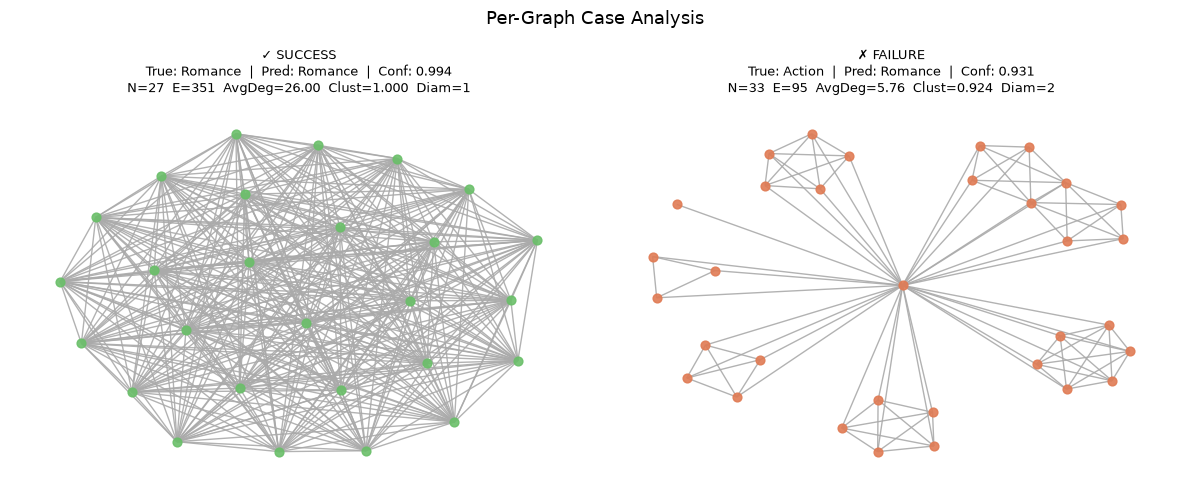

Saved: case_analysis.png


In [32]:
# ── Visualise Success & Failure graphs with stats ─────────────────────────────
class_names = ['Action', 'Romance']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, case, title_prefix in zip(axes, [success, failure], ['✓ SUCCESS', '✗ FAILURE']):
    G = to_networkx(case['data'], to_undirected=True)
    pos = nx.spring_layout(G, seed=SEED)
    color = '#6abf69' if case['correct'] else '#e07b54'
    nx.draw_networkx(G, pos, ax=ax, node_size=40, node_color=color,
                     edge_color='#aaaaaa', with_labels=False, alpha=0.9)
    s, _ = compute_graph_stats(case['data'])
    ax.set_title(
        f"{title_prefix}\n"
        f"True: {class_names[case['true']]}  |  Pred: {class_names[case['pred']]}  |  Conf: {case['confidence']:.3f}\n"
        f"N={s['nodes']}  E={s['edges']}  AvgDeg={s['avg_degree']:.2f}  "
        f"Clust={s['clustering']:.3f}  Diam={s['diameter']}",
        fontsize=9
    )
    ax.axis('off')

plt.suptitle('Per-Graph Case Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('case_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: case_analysis.png')

In [33]:
# ── Save model checkpoint ─────────────────────────────────────────────────────
torch.save({
    'model_state_dict'     : model.state_dict(),
    'optimizer_state_dict' : optimizer.state_dict(),
    'best_val_acc'         : best_val_acc,
    'seed'                 : SEED,
}, 'gin_imdb_best.pt')

print('Model saved to gin_imdb_best.pt')
print('\n=== All done! ===')

Model saved to gin_imdb_best.pt

=== All done! ===
